In [1]:
#Importing packages
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import random

import seaborn as sns

#settting a seed value allows code reproducibility!
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
#Loading dataset

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

In [3]:
#Scaling values

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7857 - val_loss: 0.5594
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5756 - val_loss: 0.7411
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5704 - val_loss: 0.4917
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4664 - val_loss: 0.4756
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4501 - val_loss: 0.4633
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4382 - val_loss: 0.4534
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4284 - val_loss: 0.4452
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4201 - val_loss: 0.4386
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4138 - val_loss: 0.4320
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4075 - val_loss: 0.4264
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4020 - val_loss: 0.4222
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

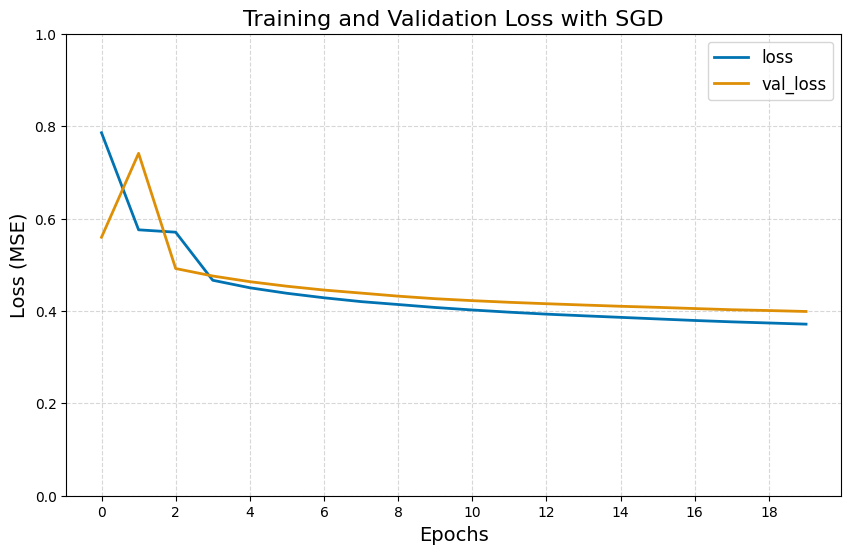

In [4]:
#MLP with SGD Optimization

#BUilding the simple MLP
model_sgd = keras.models.Sequential([
    keras.layers.Dense(30, activation = 'relu',
                       input_shape = X_train.shape[1:]),
    keras.layers.Dense(1)
])

#Compiling the model
model_sgd.compile(loss = 'mean_squared_error',
                  optimizer = keras.optimizers.SGD()
                  )

#Applying the model on training dataset and validation testing
history_sgd = model_sgd.fit(X_train, y_train, epochs = 20,
                        validation_data = (X_valid, y_valid)
                        )

#Evaluating model on test dataset
mse_test_sgd = model_sgd.evaluate(X_test, y_test)


df = pd.DataFrame(history_sgd.history)

#Colorblind-friendly palette (2 colors for loss and val_loss)
palette = sns.color_palette("colorblind", n_colors=2)

# Plot with the palette
ax = df.plot(figsize=(10, 6), linewidth=2, color=palette)

ax.set_title('Training and Validation Loss with SGD', fontsize=16)
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Loss (MSE)', fontsize=14)
ax.set_xticks(np.arange(0, 20, 2))
ax.set_ylim(0,1)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12)
plt.show()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9366 - val_loss: 0.6352
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5490 - val_loss: 0.5535
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5112 - val_loss: 0.4923
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4619 - val_loss: 0.4744
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4520 - val_loss: 0.4625
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4363 - val_loss: 0.4554
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4299 - val_loss: 0.4488
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4199 - val_loss: 0.4445
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4151 - val_loss: 0.4394
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4070 - val_loss: 0.4358
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4029 - val_loss: 0.4313
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.

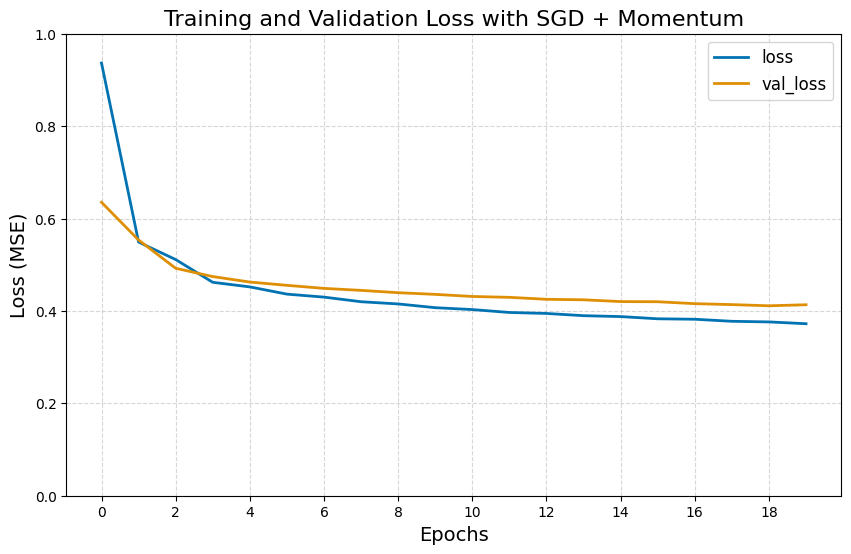

In [5]:
#MLP with SGD+Momentum Optimization

model_sgdM = keras.models.Sequential([
    keras.layers.Dense(30, activation = 'relu',
                       input_shape = X_train.shape[1:]),
    keras.layers.Dense(1)
])

model_sgdM.compile(loss = 'mean_squared_error',
                  optimizer = keras.optimizers.SGD(learning_rate = 0.001,
                                                   momentum = 0.9)
                  )

history_sgdM = model_sgdM.fit(X_train, y_train, epochs = 20,
                        validation_data = (X_valid, y_valid)
                        )

mse_test_sgdM = model_sgdM.evaluate(X_test, y_test)

df = pd.DataFrame(history_sgdM.history)

palette = sns.color_palette("colorblind", n_colors=2)
ax = df.plot(figsize=(10, 6), linewidth=2, color=palette)
ax.set_title('Training and Validation Loss with SGD + Momentum', fontsize=16)
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Loss (MSE)', fontsize=14)
ax.set_xticks(np.arange(0, 20, 2))
ax.set_ylim(0,1)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12)
plt.show()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.8535 - val_loss: 0.6261
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5648 - val_loss: 0.5482
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5107 - val_loss: 0.5126
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4814 - val_loss: 0.4915
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4631 - val_loss: 0.4784
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4509 - val_loss: 0.4695
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4422 - val_loss: 0.4631
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4355 - val_loss: 0.4583
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4301 - val_loss: 0.4545
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4256 - val_loss: 0.4512
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4217 - val_loss: 0.4485
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.

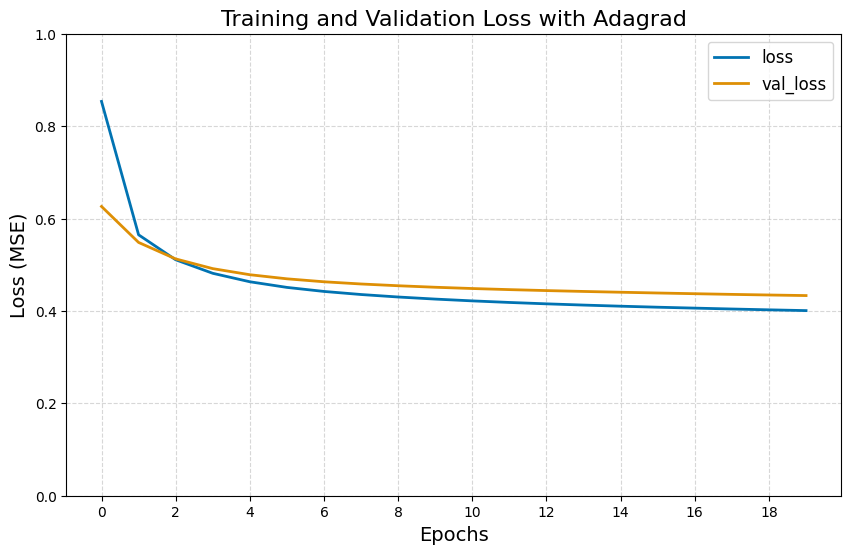

In [6]:
#MLP with Adagrad Optimization

model_Adagrad = keras.models.Sequential([
    keras.layers.Dense(30, activation = 'relu',
                       input_shape = X_train.shape[1:]),
    keras.layers.Dense(1)
])

model_Adagrad.compile(loss = 'mean_squared_error',
                  optimizer = keras.optimizers.Adagrad(learning_rate = 0.01)
                  )

history_Adagrad = model_Adagrad.fit(X_train, y_train, epochs = 20,
                        validation_data = (X_valid, y_valid)
                        )

mse_test_Adagrad = model_Adagrad.evaluate(X_test, y_test)

df = pd.DataFrame(history_Adagrad.history)

palette = sns.color_palette("colorblind", n_colors=2)
ax = df.plot(figsize=(10, 6), linewidth=2, color=palette)
ax.set_title('Training and Validation Loss with Adagrad', fontsize=16)
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Loss (MSE)', fontsize=14)
ax.set_xticks(np.arange(0, 20, 2))
ax.set_ylim(0,1)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12)
plt.show()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.3157 - val_loss: 0.6162
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5858 - val_loss: 0.5836
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6563 - val_loss: 0.6082
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7048 - val_loss: 0.6202
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7194 - val_loss: 0.6184
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7060 - val_loss: 0.6045
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6743 - val_loss: 0.5821
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6351 - val_loss: 0.5565
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5926 - val_loss: 0.5311
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5522 - val_loss: 0.5061
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5162 - val_loss: 0.4844
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.

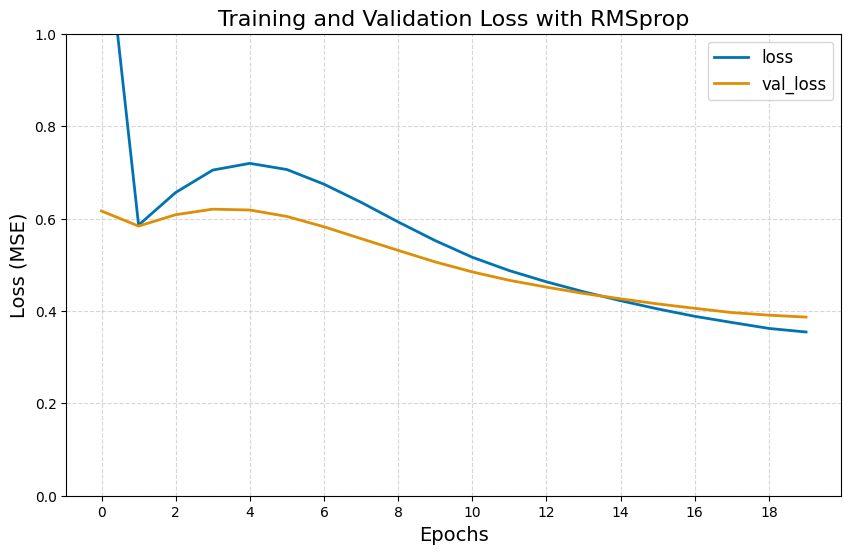

In [7]:
#MLP with RMSprop Optimization

model_RMSprop = keras.models.Sequential([
    keras.layers.Dense(30, activation = 'relu',
                       input_shape = X_train.shape[1:]),
    keras.layers.Dense(1)
])

model_RMSprop.compile(loss = 'mean_squared_error',
                  optimizer = 'RMSprop'
)

history_RMSprop = model_RMSprop.fit(X_train, y_train, epochs = 20,
                        validation_data = (X_valid, y_valid)
                        )

mse_test_RMSprop = model_RMSprop.evaluate(X_test, y_test)

df = pd.DataFrame(history_RMSprop.history)

palette = sns.color_palette("colorblind", n_colors=2)
ax = df.plot(figsize=(10, 6), linewidth=2, color=palette)
ax.set_title('Training and Validation Loss with RMSprop', fontsize=16)
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Loss (MSE)', fontsize=14)
ax.set_xticks(np.arange(0, 20, 2))
ax.set_ylim(0,1)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12)
plt.show()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.7876 - val_loss: 0.7682
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6609 - val_loss: 0.5830
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5142 - val_loss: 0.4937
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4514 - val_loss: 0.4581
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4232 - val_loss: 0.4401
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4079 - val_loss: 0.4293
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3975 - val_loss: 0.4219
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3894 - val_loss: 0.4149
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3828 - val_loss: 0.4092
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3766 - val_loss: 0.4037
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3710 - val_loss: 0.4003
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.

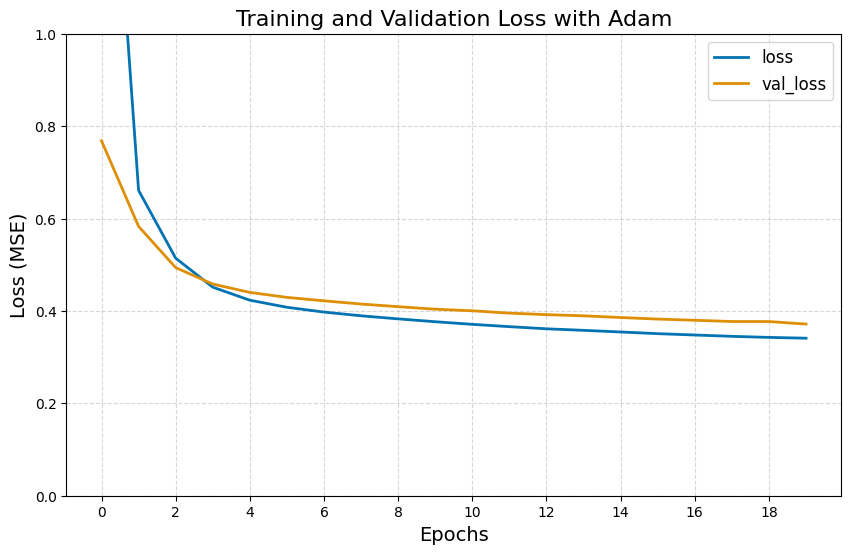

In [8]:
#MLP with ADAM optimization

model_Adam = keras.models.Sequential([
    keras.layers.Dense(30, activation = 'relu',
                       input_shape = X_train.shape[1:]),
    keras.layers.Dense(1)
])

model_Adam.compile(loss = 'mean_squared_error',
                  optimizer = 'Adam'
)

history_Adam = model_Adam.fit(X_train, y_train, epochs = 20,
                        validation_data = (X_valid, y_valid)
                        )

mse_test_Adam = model_Adam.evaluate(X_test, y_test)

df = pd.DataFrame(history_Adam.history)

palette = sns.color_palette("colorblind", n_colors=2)
ax = df.plot(figsize=(10, 6), linewidth=2, color=palette)
ax.set_title('Training and Validation Loss with Adam', fontsize=16)
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Loss (MSE)', fontsize=14)
ax.set_xticks(np.arange(0, 20, 2))
ax.set_ylim(0,1)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12)
plt.show()

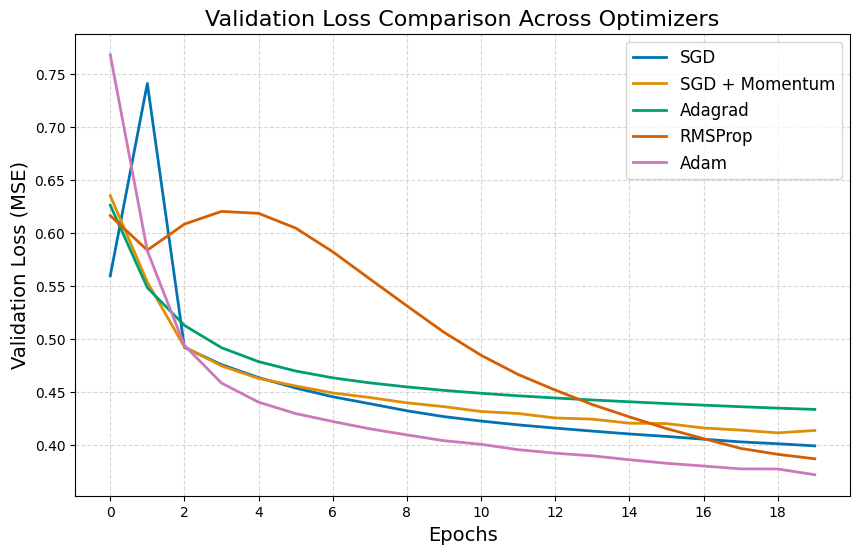

In [9]:
#Plotting validation loss comparison across optimizers

val_loss_dict = {
    'SGD': history_sgd.history['val_loss'],
    'SGD + Momentum': history_sgdM.history['val_loss'],
    'Adagrad': history_Adagrad.history['val_loss'],
    'RMSProp': history_RMSprop.history['val_loss'],
    'Adam': history_Adam.history['val_loss'],
}

df_val_loss = pd.DataFrame(val_loss_dict)

palette = sns.color_palette("colorblind", n_colors=len(df_val_loss.columns))
ax = df_val_loss.plot(figsize=(10, 6), linewidth=2, color=palette)
ax.set_title('Validation Loss Comparison Across Optimizers', fontsize=16)
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Validation Loss (MSE)', fontsize=14)
ax.set_xticks(np.arange(0, 20, 2))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12)
plt.show()

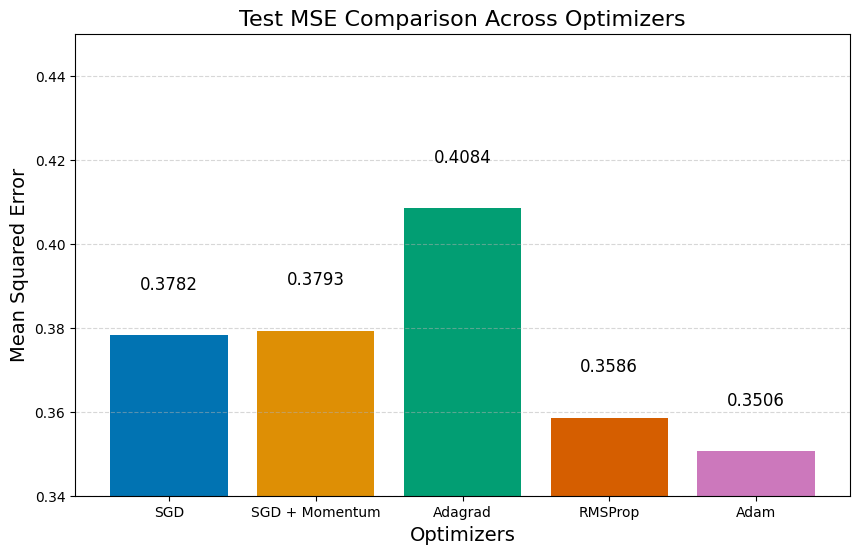

In [10]:
#Plotting test data MSE comparison across optimizers

test_mse_dict = {
    'SGD': mse_test_sgd,
    'SGD + Momentum': mse_test_sgdM,
    'Adagrad': mse_test_Adagrad,
    'RMSProp': mse_test_RMSprop,
    'Adam': mse_test_Adam,
}

models = list(test_mse_dict.keys())
mse_values = list(test_mse_dict.values())

# Colorblind-friendly palette for 5 models
palette = sns.color_palette("colorblind", n_colors=len(models))

# Create figure and axes
fig, ax = plt.subplots(figsize=(10,6))

# Create bars
bars = ax.bar(models, mse_values, color=palette)

# Titles and labels
ax.set_title('Test MSE Comparison Across Optimizers', fontsize=16)
ax.set_ylabel('Mean Squared Error', fontsize=14)
ax.set_ylim(0.34, 0.45)
ax.set_xlabel('Optimizers', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add MSE values on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}',
            ha='center', va='bottom', fontsize=12)

plt.show()